# Telecom Customer Churn — Feature Engineering

**Input:** `data/processed/churn_cleaned_v1.csv` (produced by `01_data_cleaning_and_eda.ipynb`)
**Output:** `data/processed/churn_features_v1.csv`


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the cleaned dataset

In [7]:
df = pd.read_csv("E://Sakthi//prasanth//telecom-churn-ai//data//processed//churn_cleaned_v1.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## 2. Feature: `tenure_bucket`


In [9]:
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-12", "12-24", "24-36", "36-48", "48-60", "60-72"]
df["tenure_bucket"] = pd.cut(df["tenure"], bins=bins, labels=labels, include_lowest=True)

df["tenure_bucket"].value_counts().sort_index()


tenure_bucket
0-12     2186
12-24    1024
24-36     832
36-48     762
48-60     832
60-72    1407
Name: count, dtype: int64

## 3. Feature: `is_new_customer`

In [10]:
df["is_new_customer"] = (df["tenure"] <= 6).astype(int)
df["is_new_customer"].value_counts()


is_new_customer
0    5562
1    1481
Name: count, dtype: int64

## 4. Feature: `num_services_subscribed`


In [11]:
service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]

# Count how many of these are "Yes" for each customer
df["num_services_subscribed"] = (df[service_cols] == "Yes").sum(axis=1)

df["num_services_subscribed"].value_counts().sort_index()


num_services_subscribed
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

## 5. Feature: `has_internet_and_phone`


In [12]:
df["has_internet_and_phone"] = (
    (df["PhoneService"] == "Yes") & (df["InternetService"] != "No")
).astype(int)

df["has_internet_and_phone"].value_counts()


has_internet_and_phone
1    4835
0    2208
Name: count, dtype: int64

## 6. Feature: `avg_monthly_spend`


In [13]:
df["avg_monthly_spend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"],
)

df[["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend"]].head(10)


,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000
5,8,99.65,820.50,102.562500
6,22,89.10,1949.40,88.609091
7,10,29.75,301.90,30.190000
8,28,104.80,3046.05,108.787500
9,62,56.15,3487.95,56.257258


## 7. Feature: `contract_risk_score`


In [14]:
contract_risk_map = {
    "Month-to-month": 2,
    "One year": 1,
    "Two year": 0,
}
df["contract_risk_score"] = df["Contract"].map(contract_risk_map)

df[["Contract", "contract_risk_score"]].drop_duplicates()


,Contract,contract_risk_score
0,Month-to-month,2
1,One year,1
11,Two year,0


## 8. Quick sanity check: do the new features actually separate churners from non-churners?


In [15]:
new_features = ["is_new_customer", "num_services_subscribed",
                "has_internet_and_phone", "avg_monthly_spend", "contract_risk_score"]

df.groupby("Churn")[new_features].mean().round(2)


,is_new_customer,num_services_subscribed,has_internet_and_phone,avg_monthly_spend,contract_risk_score
Churn,,,,,
0,0.13,3.45,0.63,61.27,1.11
1,0.42,3.13,0.85,74.43,1.86


**Sanity check results (read left-to-right, `Churn=0` vs `Churn=1`):**
- `is_new_customer`: much higher average for churners → confirms new customers churn more, as expected
- `num_services_subscribed`: lower for churners → fewer add-ons, less "locked in"
- `contract_risk_score`: higher for churners → confirms month-to-month risk signal carried through correctly
- `avg_monthly_spend`: higher for churners → consistent with notebook 01's finding that churners pay more


C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_10648\2844247096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Churn", y="num_services_subscribed", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_10648\2844247096.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No churn", "Churn"])
C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_10648\2844247096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Churn", y="contract_risk_score", data=df, ax=axes[1], palette=["#4C72B0", "#C44E52"])
C:\Users\L E N O V O\AppData

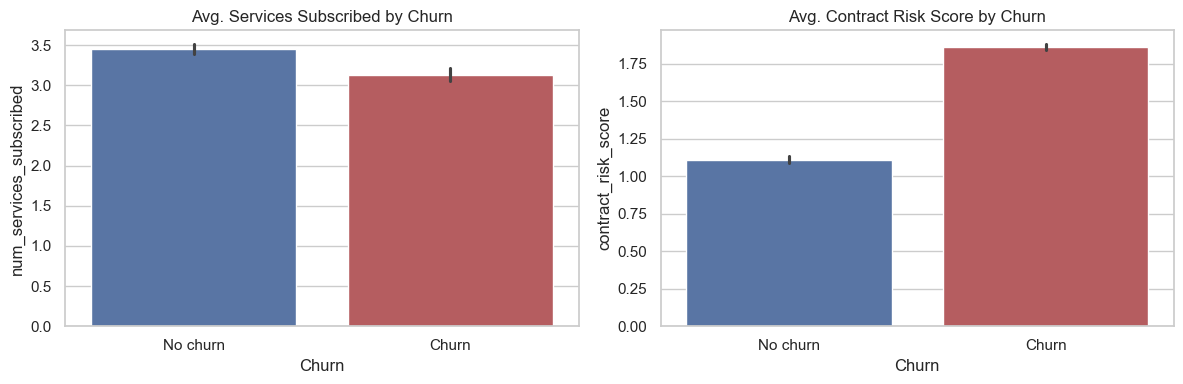

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x="Churn", y="num_services_subscribed", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Avg. Services Subscribed by Churn")
axes[0].set_xticklabels(["No churn", "Churn"])

sns.barplot(x="Churn", y="contract_risk_score", data=df, ax=axes[1], palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Avg. Contract Risk Score by Churn")
axes[1].set_xticklabels(["No churn", "Churn"])

plt.tight_layout()
plt.show()


## 9. Final feature set overview

In [17]:
print("Final shape:", df.shape)
print()
print("All columns:")
print(list(df.columns))


Final shape: (7043, 27)

All columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_bucket', 'is_new_customer', 'num_services_subscribed', 'has_internet_and_phone', 'avg_monthly_spend', 'contract_risk_score']


In [18]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,is_new_customer,num_services_subscribed,has_internet_and_phone,avg_monthly_spend,contract_risk_score
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12,1,1,0,29.850000,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-36,0,3,1,55.573529,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12,1,3,1,54.075000,2
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,36-48,0,3,0,40.905556,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12,1,1,1,75.825000,2


## 10. Save the engineered dataset

In [19]:
df.to_csv("../data/processed/churn_features_v1.csv", index=False)
print("Saved to ../data/processed/churn_features_v1.csv")
print("Shape:", df.shape)


Saved to ../data/processed/churn_features_v1.csv
Shape: (7043, 27)


## 11. Summary

**New features added (6 total), all built only from pre-churn information:**

| Feature | What it is | Why it helps |
|---|---|---|
| `tenure_bucket` | Tenure grouped into 6 ranges | Churn risk isn't linear with tenure -- buckets capture the actual shape found in EDA |
| `is_new_customer` | Flag: tenure ≤ 6 months | Makes the strongest tenure-related signal explicit |
| `num_services_subscribed` | Count of "Yes" service add-ons | Proxy for engagement / lock-in |
| `has_internet_and_phone` | Flag: bundled phone + internet | Captures bundling behavior |
| `avg_monthly_spend` | TotalCharges / tenure | Smoothed spend measure, robust to pricing changes over time |
| `contract_risk_score` | Ordinal encoding of contract type (0/1/2) | Makes the #1 EDA finding easy for simpler models to use directly |

**On class imbalance:** intentionally NOT handled here. It will be handled inside
model training (Phase 4), applied only to the training split, using `class_weight`
and/or resampling -- never baked into this shared feature file.
